## 1. Setup & Imports <a id='1'></a>

In [1]:
!pip install tensorflow
!pip install keras

In [2]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# ── Scikit-Learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm          import SVC
from sklearn.neighbors    import KNeighborsClassifier
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Advanced Models ───────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ── Deep Learning ─────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
print(f'TensorFlow: {tf.__version__}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('All imports complete.')

2026-05-10 08:50:40.853371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778403041.043475      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778403041.101786      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778403041.559482      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778403041.559523      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778403041.559526      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
All imports complete.


## 2. Data Loading & Exploration <a id='2'></a>

In [3]:
# ── Load ──────────────────────────────────────────────────────────────────────
train = pd.read_parquet('/kaggle/input/competitions/ceip-ds-lloyd-kaggle/train.parquet')
test  = pd.read_parquet('/kaggle/input/competitions/ceip-ds-lloyd-kaggle/test.parquet')

# CRITICAL FIX: target is stored as string '0'/'1' — convert to int immediately
train['target'] = train['target'].astype(int)

# Save raw copies so we can always refer back
train_raw = train.copy()
test_raw  = test.copy()

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print()
print(train.dtypes)

Train : (1639424, 7)
Test  : (409856, 7)

Date      datetime64[ns]
X1               float64
X2               float64
X3               float64
X4               float64
X5               float64
target             int64
dtype: object


In [4]:
# ── Basic Statistics ──────────────────────────────────────────────────────────
print('=== TRAIN SAMPLE ===')
display(train.head())
print('\n=== TEST SAMPLE ===')
display(test.head())
print('\n=== DESCRIPTIVE STATS (TRAIN) ===')
display(train.describe())

=== TRAIN SAMPLE ===


,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0



=== TEST SAMPLE ===


,ID,Date,X1,X2,X3,X4,X5
0,0,2020-12-16,1.685395,5.463917,1.0,7.389056,2.890372
1,1,2020-12-16,1.488844,5.454936,1.0,7.389056,2.890372
2,2,2020-12-16,1.164160,5.471136,1.0,1.000000,2.890372
3,3,2020-12-16,1.000000,5.467385,1.0,1.000000,2.890372
4,4,2020-12-16,1.000000,5.453995,1.0,1.000000,2.833213



=== DESCRIPTIVE STATS (TRAIN) ===


,Date,X1,X2,X3,X4,X5,target
count,1639424,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06
mean,2022-12-03 07:23:43.817145600,1.139258e+00,5.488189e+00,4.110388e+32,2.706323e+29,1.187219e+00,8.562764e-03
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,2021-12-10 00:00:00,1.049171e+00,5.480597e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,2022-11-30 00:00:00,1.105171e+00,5.488979e+00,1.000000e+00,1.000000e+00,6.931472e-01,0.000000e+00
75%,2023-11-23 00:00:00,1.214096e+00,5.496717e+00,1.000000e+00,2.718282e+00,2.890372e+00,0.000000e+00
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00,1.000000e+00
std,NaN,1.391992e-01,1.342811e-02,2.346156e+35,5.812988e+31,1.304814e+00,9.213820e-02


In [5]:
# ── Missing Values ────────────────────────────────────────────────────────────
print('Missing values — TRAIN:')
print(train.isnull().sum())
print('\nMissing values — TEST:')
print(test.isnull().sum())

Missing values — TRAIN:
Date      0
X1        0
X2        0
X3        0
X4        0
X5        0
target    0
dtype: int64

Missing values — TEST:
ID      0
Date    0
X1      0
X2      0
X3      0
X4      0
X5      0
dtype: int64


Class 0 (Normal)  :  1,625,386  (99.14%)
Class 1 (Anomaly) :     14,038  (0.86%)
Imbalance ratio   : 115.8:1


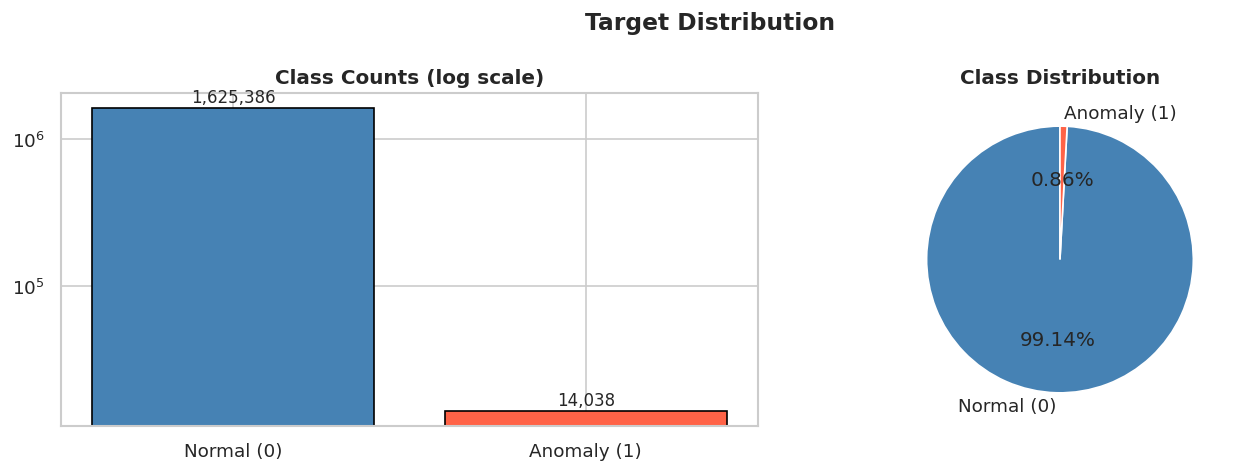

In [6]:
# ── Target Distribution ───────────────────────────────────────────────────────
counts = train['target'].value_counts()
pct    = train['target'].value_counts(normalize=True) * 100
ratio  = counts[0] / counts[1]

print(f'Class 0 (Normal)  : {counts[0]:>10,}  ({pct[0]:.2f}%)')
print(f'Class 1 (Anomaly) : {counts[1]:>10,}  ({pct[1]:.2f}%)')
print(f'Imbalance ratio   : {ratio:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bars = axes[0].bar(['Normal (0)', 'Anomaly (1)'], counts.values,
                   color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Class Counts (log scale)', fontweight='bold')
for b, v in zip(bars, counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, v*1.1, f'{v:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=['Normal (0)', 'Anomaly (1)'],
            autopct='%1.2f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Distribution', fontweight='bold')
plt.suptitle('Target Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

In [7]:
# ── Feature Insight ───────────────────────────────────────────────────────────
# X3, X4, X5 are exponential-encoded (e^n) → log() recovers integer readings
# X5 has only 32 unique values (categorical-like sensor level)
# X1, X2 are continuous sensor readings
feature_cols = ['X1', 'X2', 'X3', 'X4', 'X5']
print('Unique value counts per feature:')
for c in feature_cols:
    print(f'  {c}: {train[c].nunique():>8,} unique values')
print(f'\nDate range: {train["Date"].min().date()} → {train["Date"].max().date()}')
print(f'Unique dates: {train["Date"].nunique()}')

Unique value counts per feature:
  X1:      526 unique values
  X2:    2,812 unique values
  X3:       88 unique values
  X4:       81 unique values
  X5:       32 unique values

Date range: 2020-12-16 → 2024-12-11
Unique dates: 1432


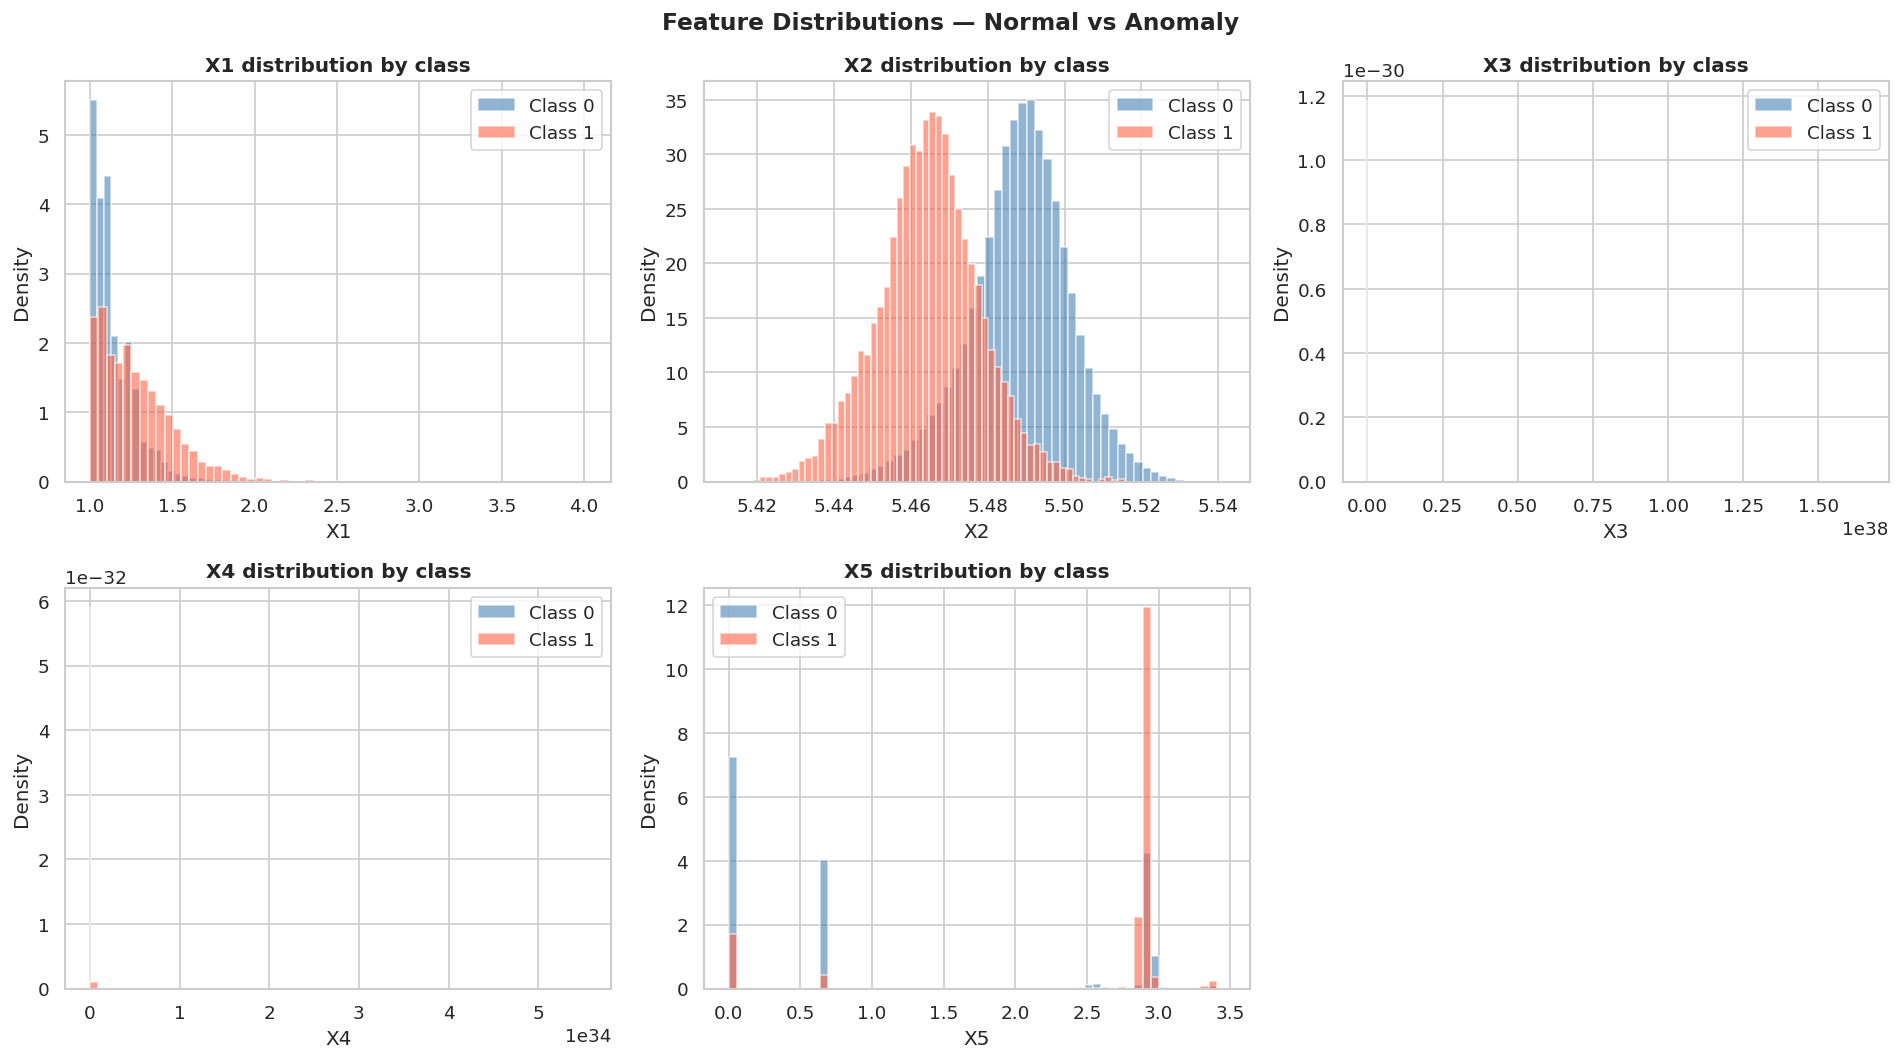

In [8]:
# ── Feature Distributions by Class ───────────────────────────────────────────
# Uses raw train_raw with target already as int
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for label, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = train_raw.loc[train_raw['target'] == label, col].values
        axes[i].hist(subset, bins=60, alpha=0.6, color=color,
                     label=f'Class {label}', density=True)
    axes[i].set_title(f'{col} distribution by class', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Feature Distributions — Normal vs Anomaly', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

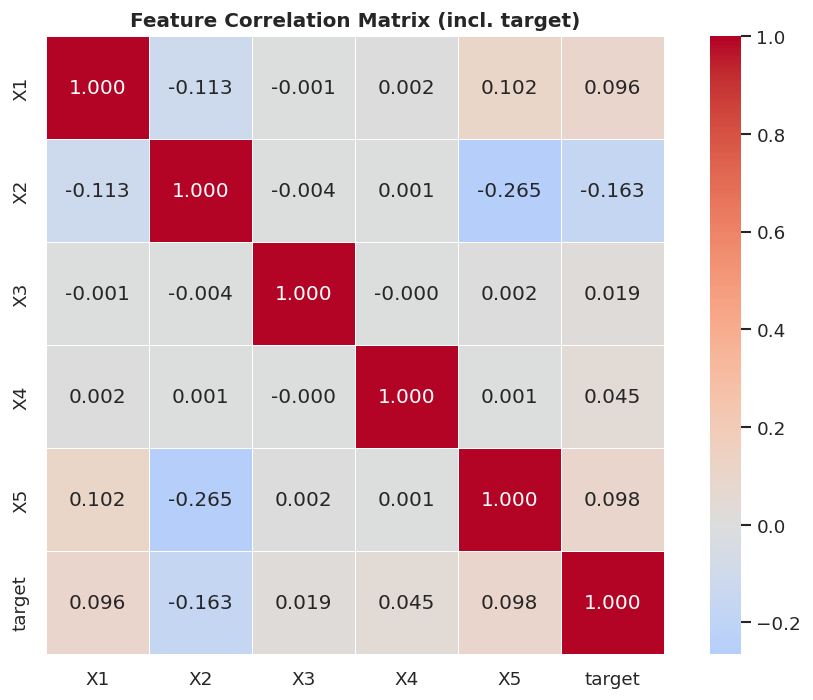

In [9]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
corr = train[feature_cols + ['target']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix (incl. target)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

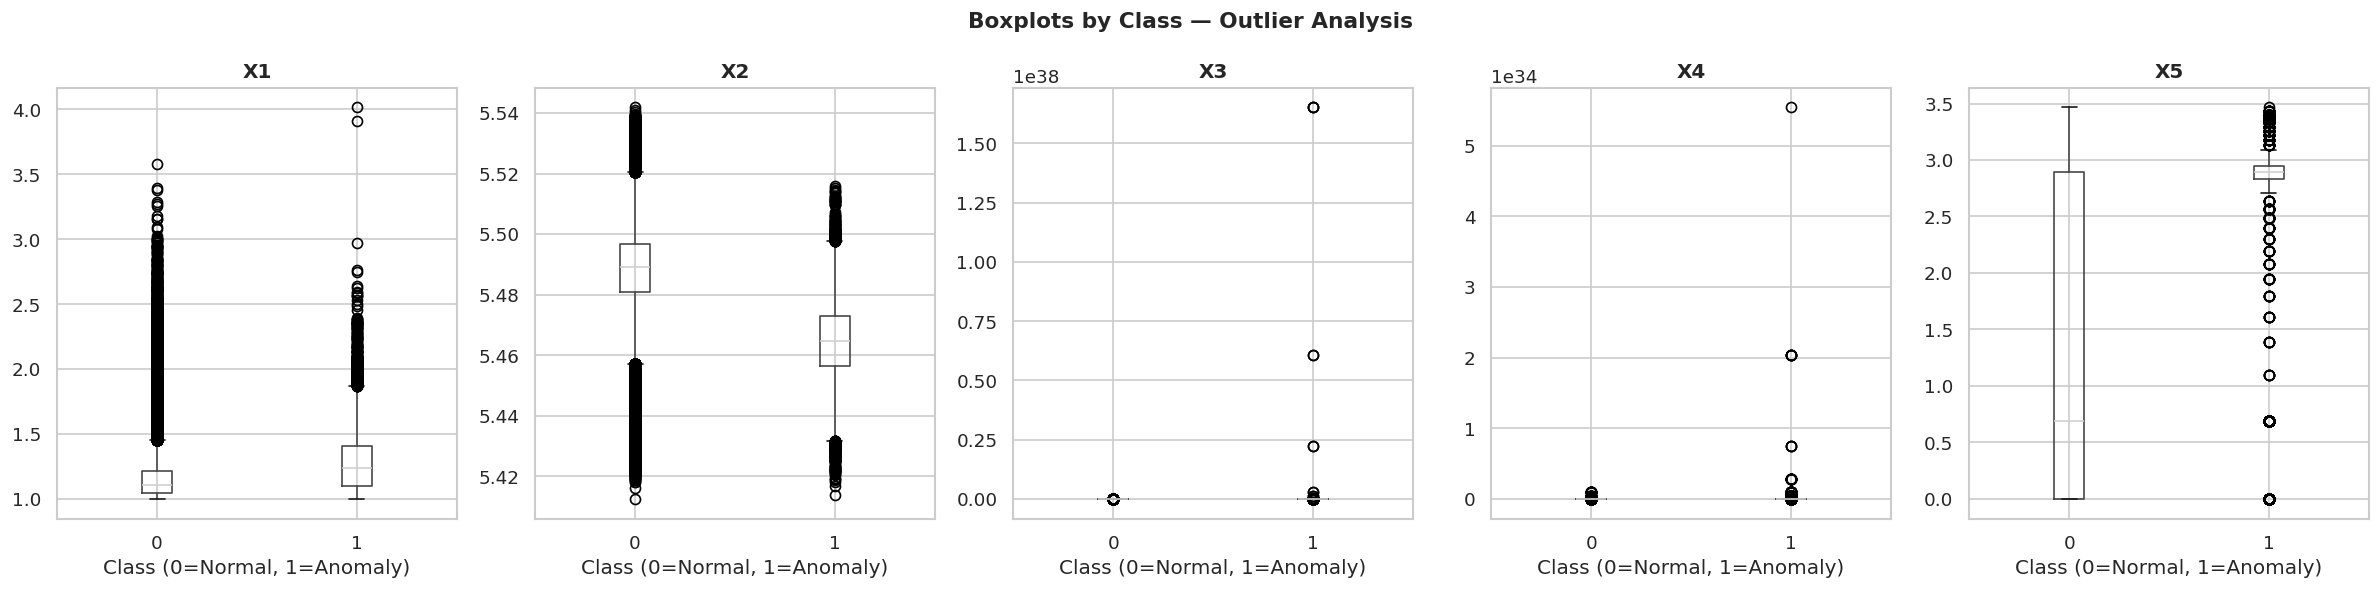

In [10]:
# ── Outlier Analysis: Boxplots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(feature_cols):
    train.boxplot(column=col, by='target', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Class (0=Normal, 1=Anomaly)')
plt.suptitle('Boxplots by Class — Outlier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()

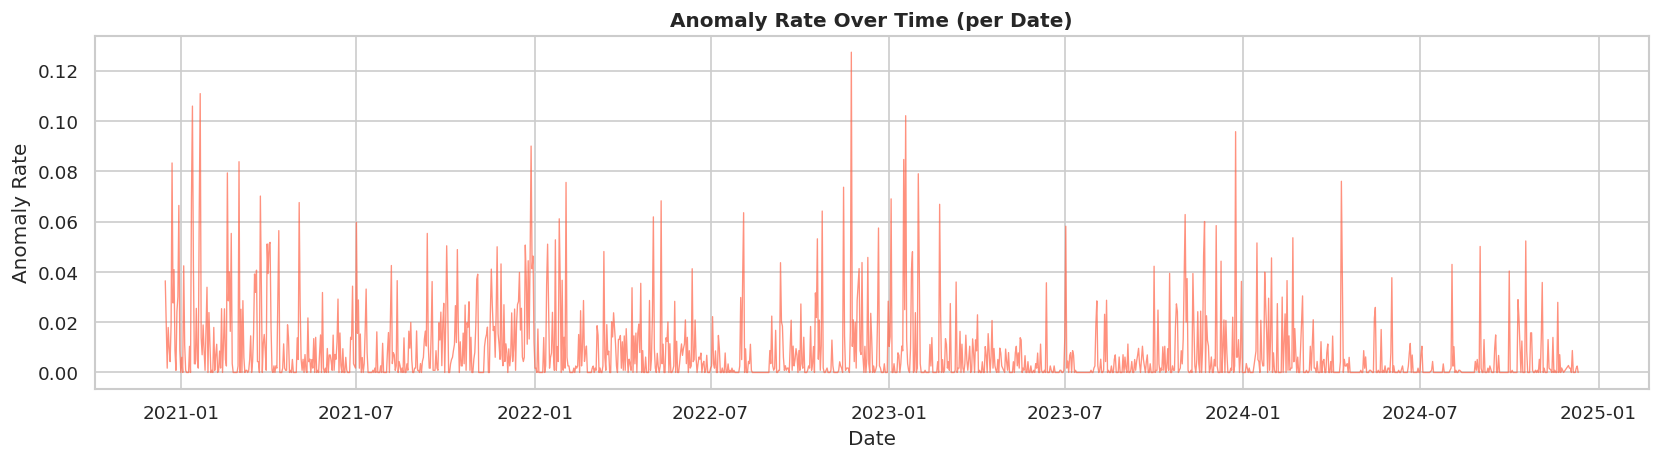

In [11]:
# ── Anomaly Rate Over Time ────────────────────────────────────────────────────
by_date = train.groupby('Date')['target'].agg(['sum', 'count'])
by_date['anomaly_rate'] = by_date['sum'] / by_date['count']

plt.figure(figsize=(14, 4))
plt.plot(by_date.index, by_date['anomaly_rate'], alpha=0.7, color='tomato', linewidth=0.8)
plt.title('Anomaly Rate Over Time (per Date)', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Anomaly Rate')
plt.tight_layout()
plt.savefig('anomaly_rate_time.png', bbox_inches='tight')
plt.show()

## 3. Preprocessing & Feature Engineering <a id='3'></a>

In [12]:
# ── Shared Preprocessing Functions ───────────────────────────────────────────
# Define once — applied identically to BOTH train and test

def extract_date_features(df):
    df = df.copy()
    df['Date']       = pd.to_datetime(df['Date'])
    df['year']       = df['Date'].dt.year
    df['month']      = df['Date'].dt.month
    df['day']        = df['Date'].dt.day
    df['dayofweek']  = df['Date'].dt.dayofweek
    df['quarter']    = df['Date'].dt.quarter
    df['weekofyear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['dayofyear']  = df['Date'].dt.dayofyear
    df = df.drop(columns=['Date'])
    return df


def engineer_features(df):
    df = df.copy()
    sensors = ['X1', 'X2', 'X3', 'X4', 'X5']

    # Log-decode exponential features (X3, X4, X5 are stored as e^n)
    for col in ['X3', 'X4', 'X5']:
        df[f'{col}_log'] = np.log1p(df[col])
    df['X1_log'] = np.log1p(df['X1'])
    df['X2_log'] = np.log1p(df['X2'])

    # Row-wise sensor statistics
    df['sensor_mean']  = df[sensors].mean(axis=1)
    df['sensor_std']   = df[sensors].std(axis=1)
    df['sensor_max']   = df[sensors].max(axis=1)
    df['sensor_min']   = df[sensors].min(axis=1)
    df['sensor_range'] = df['sensor_max'] - df['sensor_min']
    df['sensor_sum']   = df[sensors].sum(axis=1)
    df['sensor_skew']  = df[sensors].skew(axis=1)

    # Pairwise ratios
    df['X1_X2_ratio'] = df['X1'] / (df['X2'] + 1e-9)
    df['X4_X5_ratio'] = df['X4'] / (df['X5'] + 1e-9)
    df['X1_X4_ratio'] = df['X1'] / (df['X4'] + 1e-9)
    df['X2_X5_ratio'] = df['X2'] / (df['X5'] + 1e-9)

    # Differences
    df['X2_X1_diff'] = df['X2'] - df['X1']
    df['X4_X5_diff'] = df['X4'] - df['X5']
    df['X4_X3_diff'] = df['X4'] - df['X3']

    # Log-space features
    df['logX4_logX5_ratio'] = df['X4_log'] / (df['X5_log'] + 1e-9)
    df['logX3_logX4_diff']  = df['X3_log'] - df['X4_log']

    # Polynomial features
    df['X1_sq']         = df['X1'] ** 2
    df['X2_sq']         = df['X2'] ** 2
    df['X1_X2_product'] = df['X1'] * df['X2']

    # Z-scores
    row_mean = df[['X1', 'X2']].mean(axis=1)
    row_std  = df[['X1', 'X2']].std(axis=1) + 1e-9
    df['X1_zscore'] = (df['X1'] - row_mean) / row_std
    df['X2_zscore'] = (df['X2'] - row_mean) / row_std

    return df


# ── Apply to TRAIN ────────────────────────────────────────────────────────────
train_p  = extract_date_features(train)
train_fe = engineer_features(train_p)

# ── Apply to TEST (same functions, no leakage) ────────────────────────────────
test_p   = extract_date_features(test)
test_fe  = engineer_features(test_p)

print(f'Train after FE : {train_fe.shape}')
print(f'Test  after FE : {test_fe.shape}')

Train after FE : (1639424, 40)
Test  after FE : (409856, 40)


In [13]:
# ── Prepare X, y, X_submit ────────────────────────────────────────────────────
test_ids = test_fe['ID'].values

X        = train_fe.drop(columns=['target'])
y        = train_fe['target']
X_submit = test_fe.drop(columns=['ID']).reindex(columns=X.columns, fill_value=0)

print(f'X        : {X.shape}')
print(f'y        : {y.shape}  | class dist: {y.value_counts().to_dict()}')
print(f'X_submit : {X_submit.shape}')
print(f'Columns match: {list(X.columns) == list(X_submit.columns)}')

X        : (1639424, 39)
y        : (1639424,)  | class dist: {0: 1625386, 1: 14038}
X_submit : (409856, 39)
Columns match: True


In [14]:
# ── Train / Validation Split ──────────────────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'X_tr  : {X_tr.shape}  | anomalies: {y_tr.sum()}')
print(f'X_val : {X_val.shape} | anomalies: {y_val.sum()}')

X_tr  : (1311539, 39)  | anomalies: 11230
X_val : (327885, 39) | anomalies: 2808


In [15]:
# ── Scale — fit on train only, transform train + val + test ──────────────────
scaler       = StandardScaler()
X_tr_sc      = scaler.fit_transform(X_tr)       # fit here only
X_val_sc     = scaler.transform(X_val)           # transform only
X_submit_sc  = scaler.transform(X_submit)        # transform only — test data
X_full_sc    = scaler.transform(X)               # full train for final refit
print('Scaling complete')
print(f'X_submit_sc shape : {X_submit_sc.shape}')

Scaling complete
X_submit_sc shape : (409856, 39)


In [16]:
# ── SMOTE on 10% sample (for classical models only) ───────────────────────────
_, X_sm_raw, _, y_sm_raw = train_test_split(
    X_tr_sc, y_tr, test_size=0.10, stratify=y_tr, random_state=SEED
)
sm = SMOTE(random_state=SEED, k_neighbors=5)
X_sm, y_sm = sm.fit_resample(X_sm_raw, y_sm_raw)
print(f'SMOTE sample — X: {X_sm.shape} | dist: {pd.Series(y_sm).value_counts().to_dict()}')

SMOTE sample — X: (260062, 39) | dist: {0: 130031, 1: 130031}


## 4. Classical Models <a id='4'></a>

In [17]:
# ── Evaluation Helper ─────────────────────────────────────────────────────────
results = []

def evaluate(name, model, X_train, y_train, X_val, y_val, fit=True):
    if fit:
        model.fit(X_train, y_train)
    preds = model.predict(X_val)

    acc  = accuracy_score(y_val, preds)
    f1_0 = f1_score(y_val, preds, pos_label=0)
    f1_1 = f1_score(y_val, preds, pos_label=1)
    f1_m = f1_score(y_val, preds, average='macro')
    prec = precision_score(y_val, preds, average='macro', zero_division=0)
    rec  = recall_score(y_val, preds, average='macro', zero_division=0)

    print(f'\n{"─"*55}')
    print(f'  {name}')
    print(f'{"─"*55}')
    print(f'  Accuracy       : {acc:.4f}')
    print(f'  F1  (class 0)  : {f1_0:.4f}')
    print(f'  F1  (class 1)  : {f1_1:.4f}   ← anomaly detection metric')
    print(f'  F1  (macro)    : {f1_m:.4f}')
    print(classification_report(y_val, preds, target_names=['Normal', 'Anomaly']))

    results.append(dict(
        Model=name, Accuracy=acc,
        F1_class0=f1_0, F1_class1=f1_1, F1_macro=f1_m,
        Precision_macro=prec, Recall_macro=rec
    ))
    return model, preds

In [18]:
# ── 4a. Logistic Regression ───────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                        random_state=SEED, n_jobs=-1)
lr, lr_preds = evaluate('Logistic Regression', lr, X_sm, y_sm, X_val_sc, y_val)


───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
  Accuracy       : 0.9516
  F1  (class 0)  : 0.9750
  F1  (class 1)  : 0.2466   ← anomaly detection metric
  F1  (macro)    : 0.6108
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97    325077
     Anomaly       0.14      0.93      0.25      2808

    accuracy                           0.95    327885
   macro avg       0.57      0.94      0.61    327885
weighted avg       0.99      0.95      0.97    327885



In [19]:
# ── 4b. Decision Tree ─────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    max_depth=12, class_weight='balanced',
    min_samples_leaf=30, random_state=SEED
)
dt, dt_preds = evaluate('Decision Tree', dt, X_tr_sc, y_tr, X_val_sc, y_val)


───────────────────────────────────────────────────────
  Decision Tree
───────────────────────────────────────────────────────
  Accuracy       : 0.9557
  F1  (class 0)  : 0.9772
  F1  (class 1)  : 0.2653   ← anomaly detection metric
  F1  (macro)    : 0.6212
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    325077
     Anomaly       0.15      0.93      0.27      2808

    accuracy                           0.96    327885
   macro avg       0.58      0.94      0.62    327885
weighted avg       0.99      0.96      0.97    327885



In [20]:
# ── 4c. KNN (5% sample — KNN is O(n²) on large data) ─────────────────────────
_, X_knn, _, y_knn = train_test_split(
    X_sm, y_sm, test_size=0.05, stratify=y_sm, random_state=SEED
)
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)
knn, knn_preds = evaluate('KNN (5% SMOTE sample)', knn, X_knn, y_knn, X_val_sc, y_val)


───────────────────────────────────────────────────────
  KNN (5% SMOTE sample)
───────────────────────────────────────────────────────
  Accuracy       : 0.9311
  F1  (class 0)  : 0.9640
  F1  (class 1)  : 0.1892   ← anomaly detection metric
  F1  (macro)    : 0.5766
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96    325077
     Anomaly       0.11      0.94      0.19      2808

    accuracy                           0.93    327885
   macro avg       0.55      0.93      0.58    327885
weighted avg       0.99      0.93      0.96    327885



In [21]:
# ── 4d. SVM (2% sample — SVM is O(n³) on large data) ─────────────────────────
_, X_svm, _, y_svm = train_test_split(
    X_sm, y_sm, test_size=0.02, stratify=y_sm, random_state=SEED
)
svm = SVC(kernel='rbf', class_weight='balanced', random_state=SEED)
svm, svm_preds = evaluate('SVM-RBF (2% SMOTE sample)', svm, X_svm, y_svm, X_val_sc, y_val)


───────────────────────────────────────────────────────
  SVM-RBF (2% SMOTE sample)
───────────────────────────────────────────────────────
  Accuracy       : 0.9587
  F1  (class 0)  : 0.9788
  F1  (class 1)  : 0.2741   ← anomaly detection metric
  F1  (macro)    : 0.6264
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    325077
     Anomaly       0.16      0.91      0.27      2808

    accuracy                           0.96    327885
   macro avg       0.58      0.93      0.63    327885
weighted avg       0.99      0.96      0.97    327885



## 5. Advanced Ensemble Models <a id='5'></a>

In [22]:
# ── 5a. Random Forest ─────────────────────────────────────────────────────────
SEED=42
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    class_weight='balanced_subsample',
    min_samples_leaf=20, n_jobs=-1, random_state=SEED
)
rf, rf_preds = evaluate('Random Forest', rf, X_tr_sc, y_tr, X_val_sc, y_val)


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  Accuracy       : 0.9786
  F1  (class 0)  : 0.9891
  F1  (class 1)  : 0.4210   ← anomaly detection metric
  F1  (macro)    : 0.7051
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99    325077
     Anomaly       0.27      0.91      0.42      2808

    accuracy                           0.98    327885
   macro avg       0.64      0.94      0.71    327885
weighted avg       0.99      0.98      0.98    327885



In [23]:
# ── 5b. XGBoost ───────────────────────────────────────────────────────────────
spw = (y_tr == 0).sum() / (y_tr == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss', tree_method='hist',
    random_state=SEED, n_jobs=-1
)
xgb_model, xgb_preds = evaluate('XGBoost', xgb_model, X_tr_sc, y_tr, X_val_sc, y_val)


───────────────────────────────────────────────────────
  XGBoost
───────────────────────────────────────────────────────
  Accuracy       : 0.9709
  F1  (class 0)  : 0.9851
  F1  (class 1)  : 0.3564   ← anomaly detection metric
  F1  (macro)    : 0.6707
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99    325077
     Anomaly       0.22      0.94      0.36      2808

    accuracy                           0.97    327885
   macro avg       0.61      0.96      0.67    327885
weighted avg       0.99      0.97      0.98    327885



In [24]:
# ── 5c. LightGBM ──────────────────────────────────────────────────────────────
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, num_leaves=63,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, class_weight='balanced',
    random_state=SEED, n_jobs=-1, verbose=-1
)
lgb_model, lgb_preds = evaluate('LightGBM', lgb_model, X_tr_sc, y_tr, X_val_sc, y_val)


───────────────────────────────────────────────────────
  LightGBM
───────────────────────────────────────────────────────
  Accuracy       : 0.9880
  F1  (class 0)  : 0.9939
  F1  (class 1)  : 0.5642   ← anomaly detection metric
  F1  (macro)    : 0.7790
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    325077
     Anomaly       0.41      0.91      0.56      2808

    accuracy                           0.99    327885
   macro avg       0.70      0.95      0.78    327885
weighted avg       0.99      0.99      0.99    327885



In [25]:
# ── 5d. CatBoost ──────────────────────────────────────────────────────────────
cat_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced',
    eval_metric='F1', random_seed=SEED, verbose=100
)
cat_model, cat_preds = evaluate('CatBoost', cat_model, X_tr_sc, y_tr, X_val_sc, y_val)

0:	learn: 0.9294848	total: 241ms	remaining: 2m
100:	learn: 0.9480409	total: 18.3s	remaining: 1m 12s
200:	learn: 0.9528180	total: 36.9s	remaining: 54.8s
300:	learn: 0.9570138	total: 55.9s	remaining: 37s
400:	learn: 0.9614765	total: 1m 14s	remaining: 18.5s
499:	learn: 0.9639867	total: 1m 33s	remaining: 0us

───────────────────────────────────────────────────────
  CatBoost
───────────────────────────────────────────────────────
  Accuracy       : 0.9615
  F1  (class 0)  : 0.9802
  F1  (class 1)  : 0.2969   ← anomaly detection metric
  F1  (macro)    : 0.6386
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    325077
     Anomaly       0.18      0.95      0.30      2808

    accuracy                           0.96    327885
   macro avg       0.59      0.96      0.64    327885
weighted avg       0.99      0.96      0.97    327885



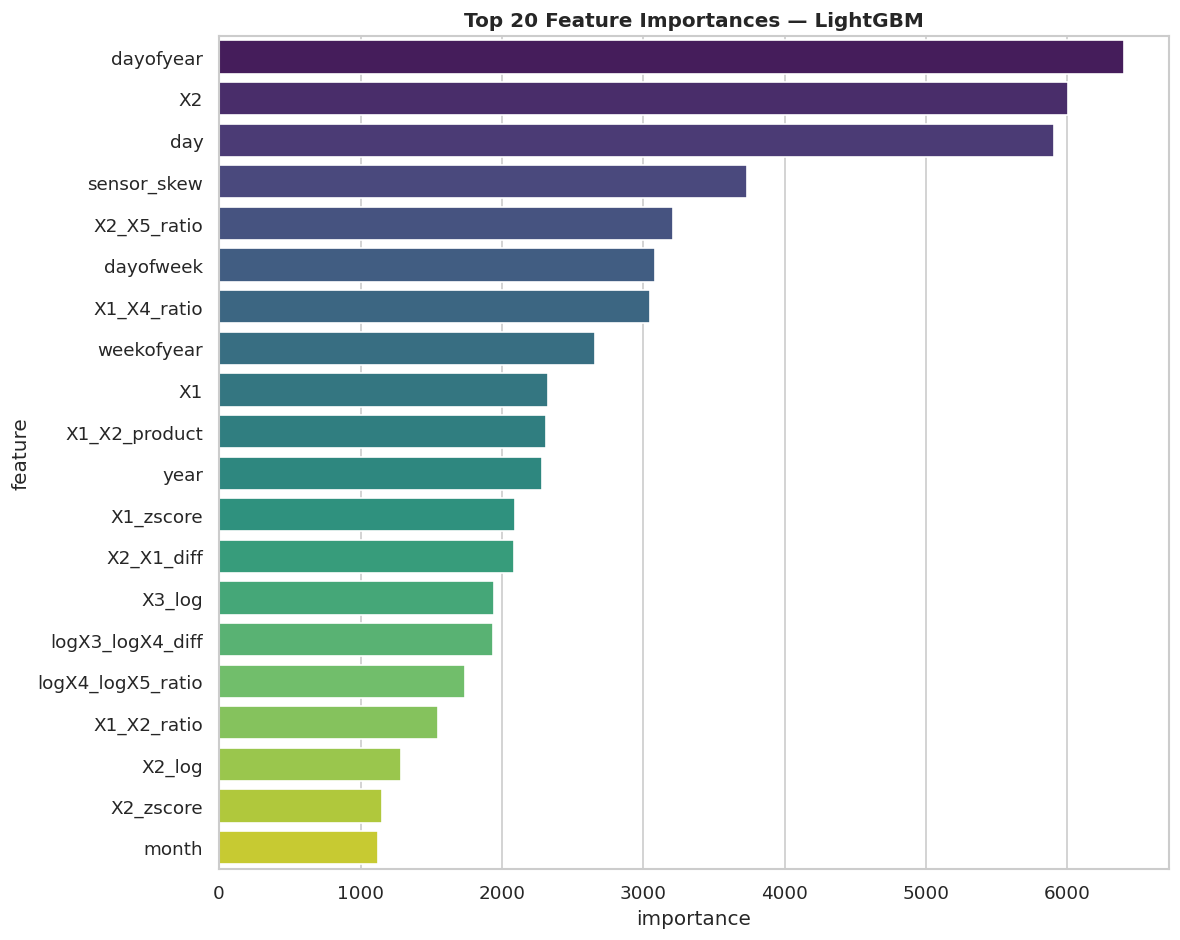

,feature,importance
12,dayofyear,6397
1,X2,6005
7,day,5904
24,sensor_skew,3734
28,X2_X5_ratio,3210
8,dayofweek,3086
27,X1_X4_ratio,3051
10,weekofyear,2657
0,X1,2329
36,X1_X2_product,2312


In [26]:
# ── Feature Importance (LightGBM) ─────────────────────────────────────────────
feat_imp = pd.DataFrame({
    'feature':    X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances — LightGBM', fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
display(feat_imp.head(10))

## 6. Neural Network <a id='6'></a>

In [27]:
# ── Build ─────────────────────────────────────────────────────────────────────
def build_nn(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

nn = build_nn(X_tr_sc.shape[1])
nn.summary()

I0000 00:00:1778403806.787756      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 39)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,041 (215.00 KB)

 Trainable params: 54,273 (212.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [28]:
# ── Train ─────────────────────────────────────────────────────────────────────
total = len(y_tr)
cw = {0: total / (2 * (y_tr == 0).sum()),
      1: total / (2 * (y_tr == 1).sum())}
print('Class weights:', cw)

nn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
cbs = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]
history = nn.fit(
    X_tr_sc, y_tr,
    validation_data=(X_val_sc, y_val),
    epochs=30, batch_size=2048,
    class_weight=cw,
    callbacks=cbs, verbose=1
)

Class weights: {0: np.float64(0.5043182043652701), 1: np.float64(58.394434550311665)}
Epoch 1/30


I0000 00:00:1778403811.616528     136 service.cc:152] XLA service 0x89be8980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778403811.616572     136 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778403812.131776     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


 45/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7705 - auc: 0.8988 - loss: 0.4296

I0000 00:00:1778403815.144273     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


641/641 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9066 - auc: 0.9674 - loss: 0.2256 - val_accuracy: 0.9423 - val_auc: 0.9858 - val_loss: 0.1520 - learning_rate: 0.0010
Epoch 2/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9392 - auc: 0.9834 - loss: 0.1618 - val_accuracy: 0.9461 - val_auc: 0.9861 - val_loss: 0.1501 - learning_rate: 0.0010
Epoch 3/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9439 - auc: 0.9845 - loss: 0.1559 - val_accuracy: 0.9489 - val_auc: 0.9870 - val_loss: 0.1423 - learning_rate: 0.0010
Epoch 4/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9447 - auc: 0.9853 - loss: 0.1521 - val_accuracy: 0.9525 - val_auc: 0.9875 - val_loss: 0.1405 - learning_rate: 0.0010
Epoch 5/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9475 - auc: 0.9856 - loss: 0.1503 - val_accuracy: 0.9562 - val_auc: 0.9873 - val_loss: 0.1305 - learning_rate: 0.0010
Epoch 6/30
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9477 - auc: 0.9862 - lo

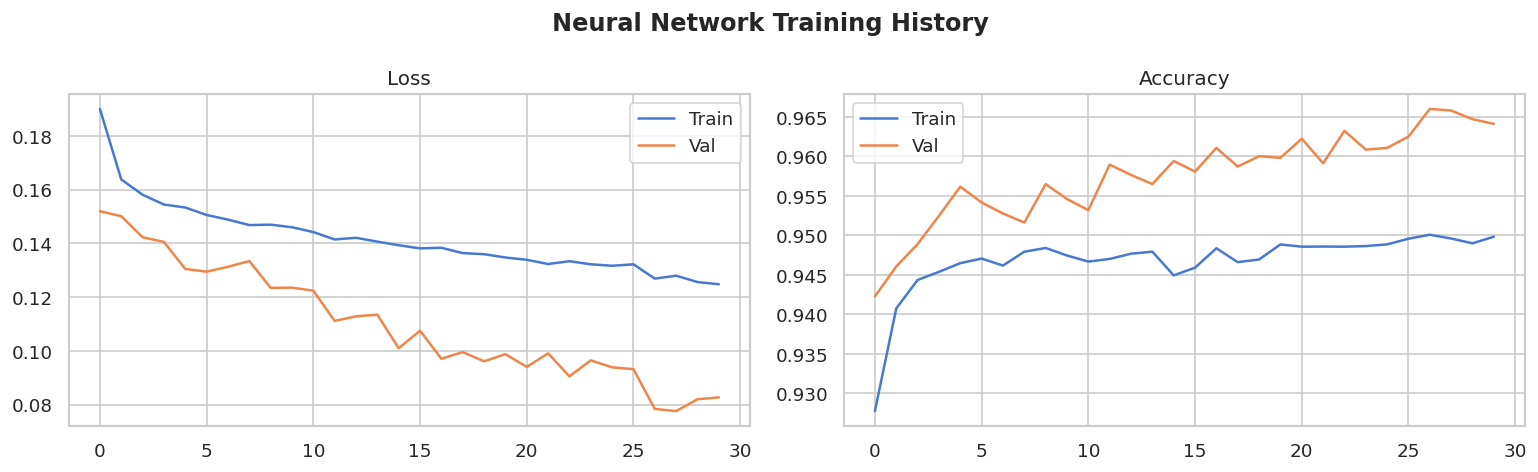

In [29]:
# ── Training Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend()
plt.suptitle('Neural Network Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('nn_curves.png', bbox_inches='tight')
plt.show()

In [30]:
# ── Threshold Tuning for best Macro-F1 ────────────────────────────────────────
nn_probs = nn.predict(X_val_sc, batch_size=4096).flatten()

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.05, 0.95, 0.025):
    f1t = f1_score(y_val, (nn_probs >= t).astype(int), average='macro')
    if f1t > best_f1:
        best_f1, best_thresh = f1t, t

print(f'Best threshold : {best_thresh:.3f}  →  Macro-F1 = {best_f1:.4f}')
nn_preds = (nn_probs >= best_thresh).astype(int)

results.append(dict(
    Model='Neural Network',
    Accuracy        = accuracy_score(y_val, nn_preds),
    F1_class0       = f1_score(y_val, nn_preds, pos_label=0),
    F1_class1       = f1_score(y_val, nn_preds, pos_label=1),
    F1_macro        = f1_score(y_val, nn_preds, average='macro'),
    Precision_macro = precision_score(y_val, nn_preds, average='macro', zero_division=0),
    Recall_macro    = recall_score(y_val, nn_preds, average='macro', zero_division=0),
))
print(classification_report(y_val, nn_preds, target_names=['Normal', 'Anomaly']))

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Best threshold : 0.925  →  Macro-F1 = 0.8214
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    325077
     Anomaly       0.72      0.59      0.65      2808

    accuracy                           0.99    327885
   macro avg       0.86      0.79      0.82    327885
weighted avg       0.99      0.99      0.99    327885



## 7. Model Evaluation & Comparison <a id='7'></a>

In [31]:
# ── Summary Table ─────────────────────────────────────────────────────────────
results_df = (pd.DataFrame(results)
              .sort_values('F1_macro', ascending=False)
              .reset_index(drop=True))

float_cols = results_df.select_dtypes('float').columns
display(results_df.style
        .background_gradient(subset=['F1_macro', 'F1_class1', 'Accuracy'], cmap='RdYlGn')
        .format('{:.4f}', subset=float_cols)
        .set_caption('📊 Model Comparison — Validation Set'))

,Model,Accuracy,F1_class0,F1_class1,F1_macro,Precision_macro,Recall_macro
0,Neural Network,0.9945,0.9972,0.6455,0.8214,0.8575,0.7919
1,LightGBM,0.9880,0.9939,0.5642,0.7790,0.7041,0.9491
2,Random Forest,0.9786,0.9891,0.4210,0.7051,0.6365,0.9449
3,XGBoost,0.9709,0.9851,0.3564,0.6707,0.6096,0.9565
4,CatBoost,0.9615,0.9802,0.2969,0.6386,0.5878,0.9550
5,SVM-RBF (2% SMOTE sample),0.9587,0.9788,0.2741,0.6264,0.5803,0.9345
6,Decision Tree,0.9557,0.9772,0.2653,0.6212,0.5770,0.9448
7,Logistic Regression,0.9516,0.9750,0.2466,0.6108,0.5708,0.9389
8,KNN (5% SMOTE sample),0.9311,0.9640,0.1892,0.5766,0.5523,0.9349


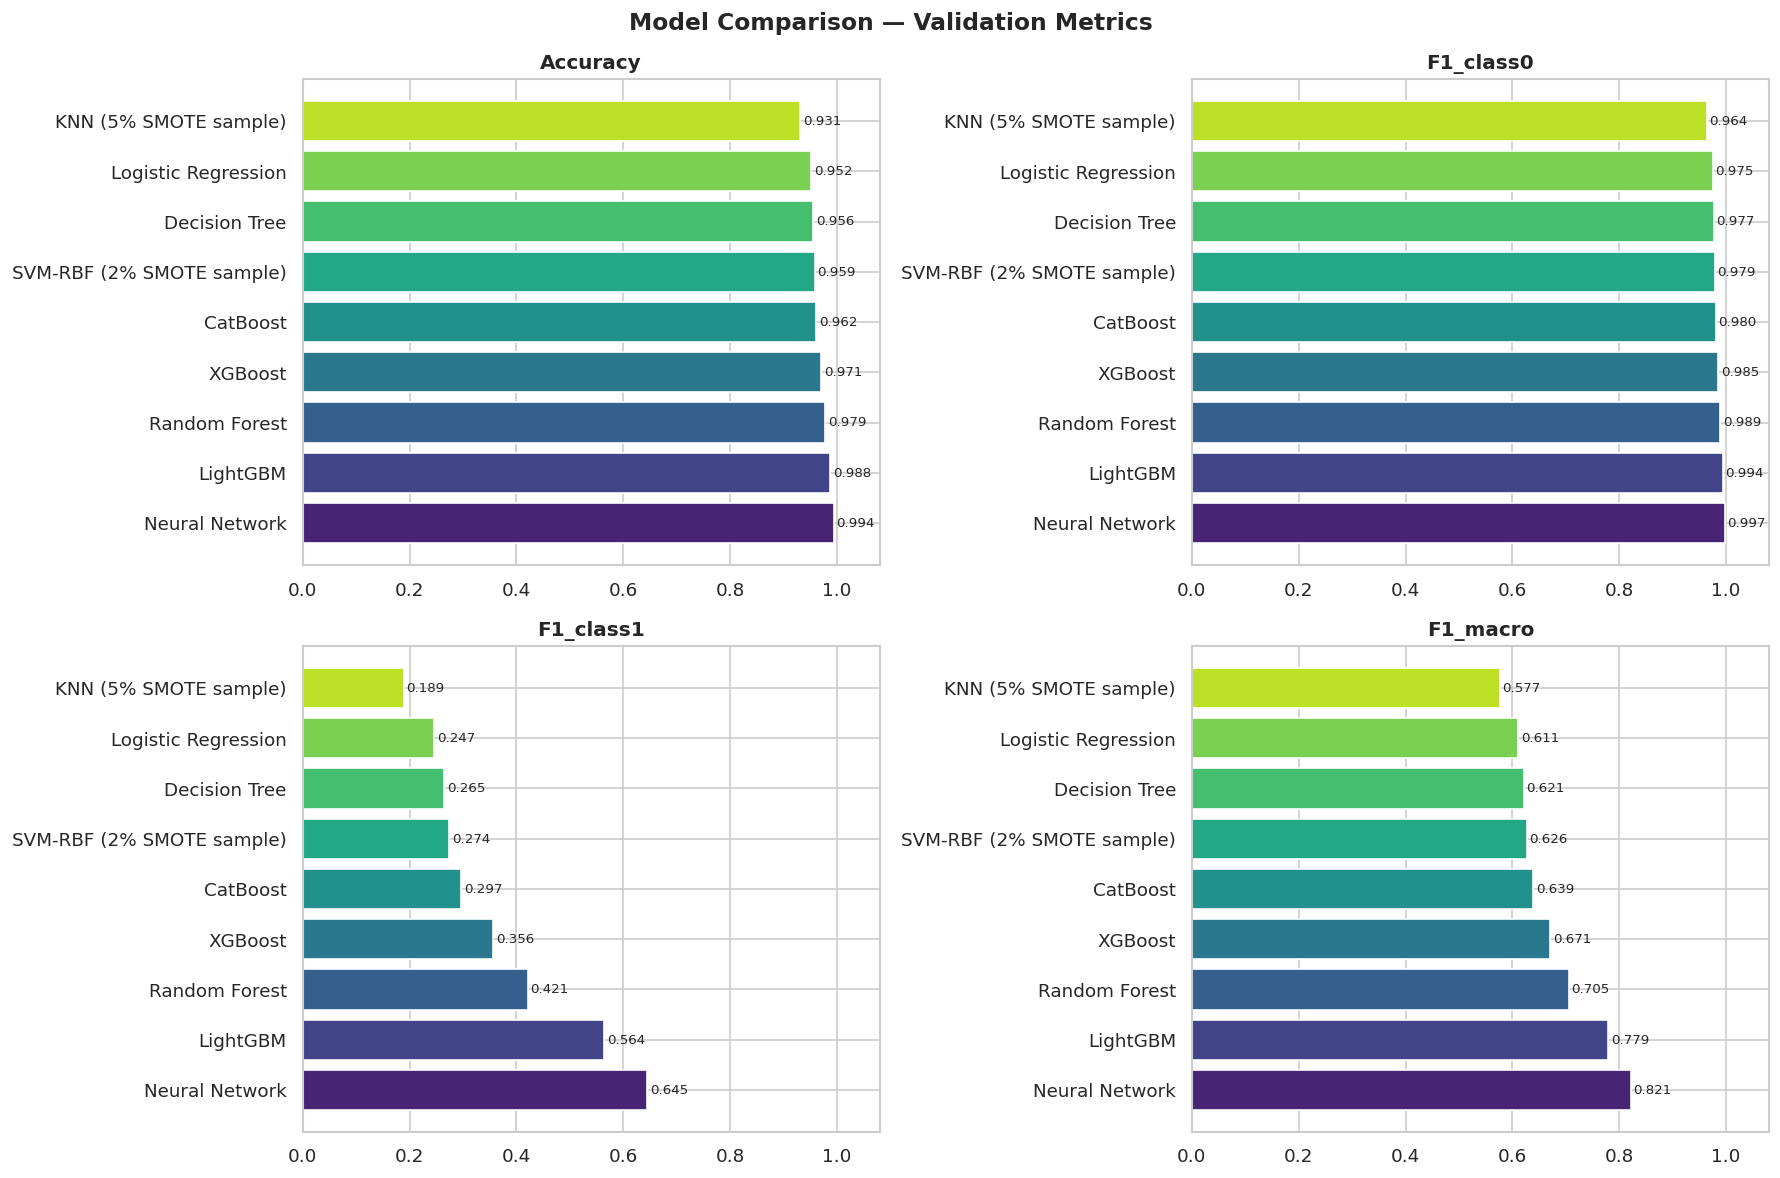

In [32]:
# ── Bar Chart Comparison ──────────────────────────────────────────────────────
metrics = ['Accuracy', 'F1_class0', 'F1_class1', 'F1_macro']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
colors = sns.color_palette('viridis', len(results_df))
for idx, metric in enumerate(metrics):
    bars = axes[idx].barh(results_df['Model'], results_df[metric], color=colors)
    axes[idx].set_title(metric, fontweight='bold')
    axes[idx].set_xlim(0, 1.08)
    for bar, val in zip(bars, results_df[metric]):
        axes[idx].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                       f'{val:.3f}', va='center', fontsize=8)
plt.suptitle('Model Comparison — Validation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

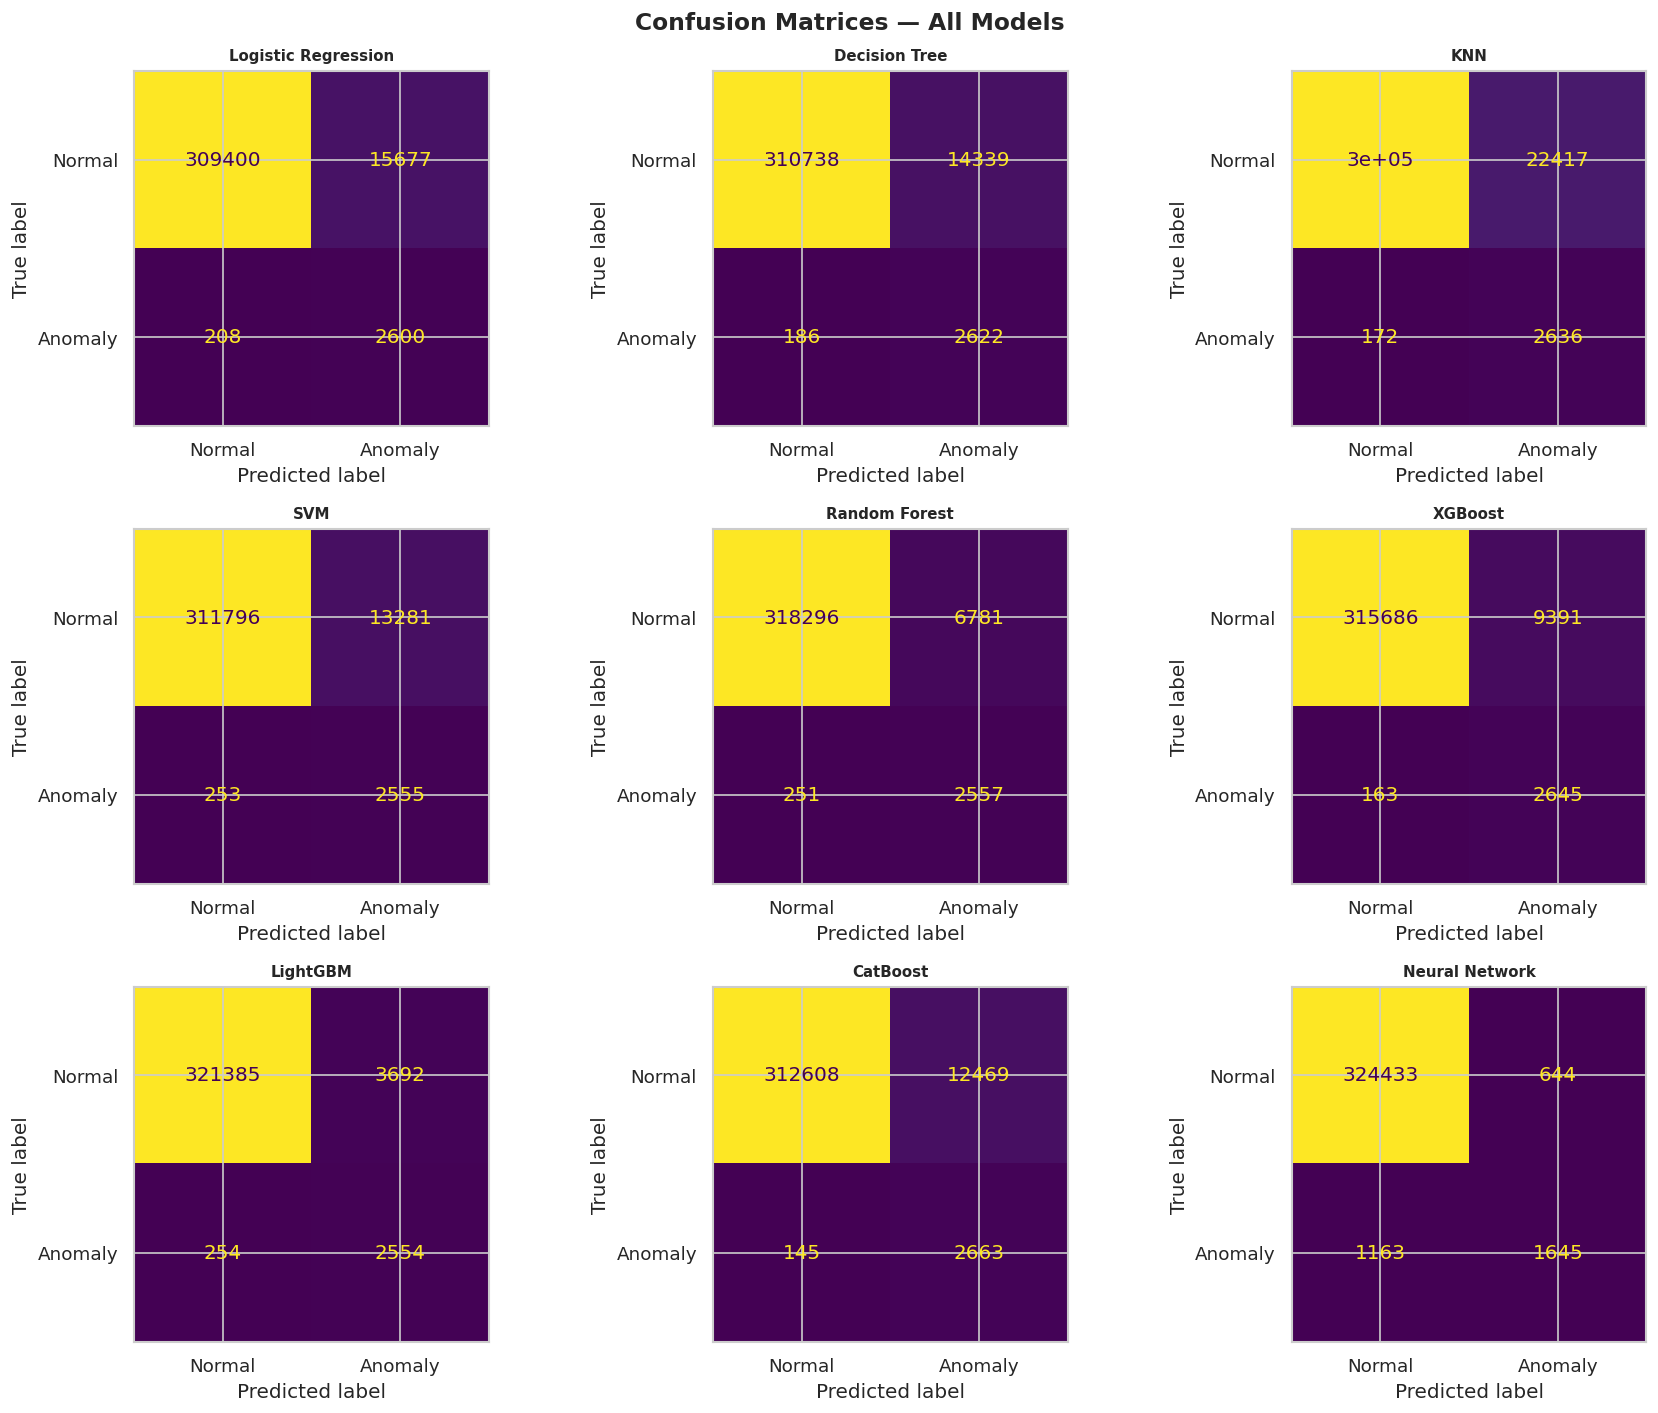

In [33]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
model_preds_dict = {
    'Logistic Regression':    lr_preds,
    'Decision Tree':          dt_preds,
    'KNN':                    knn_preds,
    'SVM':                    svm_preds,
    'Random Forest':          rf_preds,
    'XGBoost':                xgb_preds,
    'LightGBM':               lgb_preds,
    'CatBoost':               cat_preds,
    'Neural Network':         nn_preds,
}
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for ax, (name, preds) in zip(axes, model_preds_dict.items()):
    cm = confusion_matrix(y_val, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomaly']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontweight='bold', fontsize=9)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

In [34]:
# ── Define best_name & best_obj (skipping slow 5-Fold CV on 1.6M rows) ────────
# Val set = 327,884 rows — already a reliable performance estimate

results_df = (pd.DataFrame(results)
              .sort_values('F1_macro', ascending=False)
              .reset_index(drop=True))

best_name = results_df.iloc[0]['Model']

model_map = {
    'LightGBM':            lgb_model,
    'XGBoost':             xgb_model,
    'CatBoost':            cat_model,
    'Random Forest':       rf,
    'Decision Tree':       dt,
    'Logistic Regression': lr,
    'Neural Network':      None,
}
best_obj = model_map.get(best_name, lgb_model)
if best_obj is None:
    best_obj = lgb_model
    print('NN selected — using LightGBM for final predictions')

print(f'   Best Model : {best_name}')
print(f'   Val F1 (macro)   : {results_df.iloc[0]["F1_macro"]:.4f}')
print(f'   Val F1 (class 1) : {results_df.iloc[0]["F1_class1"]:.4f}')
print(f'   Val Accuracy     : {results_df.iloc[0]["Accuracy"]:.4f}')


NN selected — using LightGBM for final predictions
   Best Model : Neural Network
   Val F1 (macro)   : 0.8214
   Val F1 (class 1) : 0.6455
   Val Accuracy     : 0.9945


In [35]:
# ── Residual / Error Analysis ─────────────────────────────────────────────────
best_val_preds = model_preds_dict.get(best_name, lgb_preds)

err_df = X_val.copy()
err_df['y_true']  = y_val.values
err_df['y_pred']  = best_val_preds

fn_mask = (err_df['y_true'] == 1) & (err_df['y_pred'] == 0)
fp_mask = (err_df['y_true'] == 0) & (err_df['y_pred'] == 1)
tp_mask = (err_df['y_true'] == 1) & (err_df['y_pred'] == 1)

print(f'False Negatives (missed anomalies) : {fn_mask.sum():,}')
print(f'False Positives (false alarms)     : {fp_mask.sum():,}')
print(f'True  Positives (correct anomaly)  : {tp_mask.sum():,}')
print(f'FN Rate                            : {fn_mask.sum()/(fn_mask.sum()+tp_mask.sum()+1e-9):.4f}')

print('\n--- Feature stats: False Negatives vs True Positives ---')
display(pd.concat([
    err_df[fn_mask][feature_cols].describe().T[['mean','std']]
      .rename(columns={'mean':'FN_mean','std':'FN_std'}),
    err_df[tp_mask][feature_cols].describe().T[['mean','std']]
      .rename(columns={'mean':'TP_mean','std':'TP_std'})
], axis=1))

False Negatives (missed anomalies) : 1,163
False Positives (false alarms)     : 644
True  Positives (correct anomaly)  : 1,645
FN Rate                            : 0.4142

--- Feature stats: False Negatives vs True Positives ---


,FN_mean,FN_std,TP_mean,TP_std
X1,1.241438e+00,2.235202e-01,1.312779e+00,2.262440e-01
X2,5.470069e+00,1.199570e-02,5.460221e+00,1.315136e-02
X3,2.968473e+20,8.340413e+21,1.029493e+35,4.072860e+36
X4,1.034051e+30,1.663939e+31,4.188342e+31,5.533218e+32
X5,2.533549e+00,9.776584e-01,2.618697e+00,8.433517e-01


## 8. Final Submission <a id='8'></a>

In [36]:
# ── Retrain Best Model on FULL Train Data ─────────────────────────────────────
print(f'Retraining {best_name} on full training data ({len(X):,} rows)...')
best_obj.fit(X_full_sc, y)


Retraining Neural Network on full training data (1,639,424 rows)...


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=1000, n_jobs=-1, num_leaves=63,
               random_state=42, subsample=0.8, verbose=-1)

In [37]:
# ── Predict on Test Set ───────────────────────────────────────────────────────
# X_submit_sc was already scaled in Section 3 using the same scaler
print(f'Predicting on test set ({X_submit_sc.shape[0]:,} rows)...')
final_preds = best_obj.predict(X_submit_sc)

print(f'\nPrediction distribution:')
pred_series = pd.Series(final_preds)
print(pred_series.value_counts())
print(f'Anomaly rate in test predictions: {pred_series.mean()*100:.3f}%')

Predicting on test set (409,856 rows)...

Prediction distribution:
0    401474
1      8382
Name: count, dtype: int64
Anomaly rate in test predictions: 2.045%


In [38]:
# ── Verify test_ids and predictions align ─────────────────────────────────────
print(f'test_ids length   : {len(test_ids)}')
print(f'final_preds length: {len(final_preds)}')


test_ids length   : 409856
final_preds length: 409856


In [39]:
# ── Save Submission CSV ───────────────────────────────────────────────────────
submission = pd.DataFrame({
    'ID':     test_ids,
    'target': final_preds
})

submission.to_csv('submission.csv', index=False)

print(f'Shape: {submission.shape}')
display(submission.head(10))

Shape: (409856, 2)


,ID,target
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,0
8,8,1
9,9,0


In [40]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('='*62)
print('  COMPETITION NOTEBOOK — FINAL SUMMARY')
print('='*62)
print(f'  Best Model         : {best_name}')
print(f'  Val Accuracy       : {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'  Val F1 (Class 0)   : {results_df.iloc[0]["F1_class0"]:.4f}')
print(f'  Val F1 (Class 1)   : {results_df.iloc[0]["F1_class1"]:.4f}  <- anomaly')
print(f'  Val F1 (Macro)     : {results_df.iloc[0]["F1_macro"]:.4f}')
print(f'  Test predictions   : {int((final_preds==0).sum()):,} Normal | {int((final_preds==1).sum()):,} Anomaly')
print('='*62)



  COMPETITION NOTEBOOK — FINAL SUMMARY
  Best Model         : Neural Network
  Val Accuracy       : 0.9945
  Val F1 (Class 0)   : 0.9972
  Val F1 (Class 1)   : 0.6455  <- anomaly
  Val F1 (Macro)     : 0.8214
  Test predictions   : 401,474 Normal | 8,382 Anomaly
